# DBSCAN

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import matplotlib.cm as cm

import warnings

warnings.filterwarnings('ignore')

In [2]:
data = pd.read_excel('E:/machine_learning_1/ML1_group_assignemnt/Madrid_Rental_Properties_ML1-/raw_data/Houses for rent in Madrid.xlsx')
print(f"Shape: {data.shape}")
data.head()

Shape: (2089, 15)


,Id,District,Address,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,1,Ciudad Lineal,Piso en Quintana,NaN,Quintana,1300,2.0,72,3.0,1.0,1.0,0,0,0,0
1,2,Ciudad Lineal,Piso en calle de Arturo Soria,NaN,Costillares,3000,5.0,260,2.0,1.0,1.0,0,0,0,0
2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,4,Colina,1300,2.0,100,3.0,1.0,1.0,0,0,0,0
3,4,Ciudad Lineal,Piso en calle Badajoz,NaN,San Pascual,1600,3.0,120,4.0,1.0,1.0,0,0,0,0
4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,9,Ventas,800,2.0,60,3.0,1.0,0.0,0,0,0,0


In [3]:
# drop selected columns (like we did in K-means)
data_clean = data.drop(columns=['Id', 'Address', 'Number', 'Area'])
print(f"Shape after dropping columns: {data_clean.shape}")


Shape after dropping columns: (2089, 11)


In [4]:
data_clean.loc[data_clean['Floor'] > 30, 'Floor'] = np.nan

In [5]:
data_clean.columns = data_clean.columns.str.lower().str.replace('.', '_', regex=False)
data_clean = data_clean.rename(columns={'sq_mt': 'square_meters'})
print(data_clean.columns.tolist())

['district', 'rent', 'bedrooms', 'square_meters', 'floor', 'outer', 'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached']


In [6]:
# impute missing values
data_clean['bedrooms'] = data_clean['bedrooms'].fillna(data_clean['bedrooms'].median())
data_clean['floor'] = data_clean['floor'].fillna(data_clean['floor'].median())
data_clean['outer'] = data_clean['outer'].fillna(data_clean['outer'].mode()[0])
data_clean['elevator'] = data_clean['elevator'].fillna(data_clean['elevator'].mode()[0])

print("Remaining nulls:\n", data_clean.isnull().sum())

Remaining nulls:
 district         0
rent             0
bedrooms         0
square_meters    0
floor            0
outer            0
elevator         0
penthouse        0
cottage          0
duplex           0
semidetached     0
dtype: int64


In [7]:
def remove_outliers_iqr(data, column, factor=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    before = len(data)
    df_filtered = data[(data[column] >= lower) & (data[column] <= upper)]
    print(f"{column}: removed {before - len(df_filtered)} outliers (range: {lower:.0f} - {upper:.0f})")
    return df_filtered

data_clean = remove_outliers_iqr(data_clean, 'rent')
data_clean = remove_outliers_iqr(data_clean, 'square_meters')

print(f"\nFinal shape after outlier removal: {data_clean.shape}")

rent: removed 94 outliers (range: -1375 - 4825)
square_meters: removed 153 outliers (range: -32 - 228)

Final shape after outlier removal: (1842, 11)


### Feature Selection + Scaling (no district)

In [8]:
numerical_features = ['rent', 'bedrooms', 'square_meters', 'floor']
binary_features = ['outer', 'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached']

# features above will be used as clustering variables to help us determine clusters
clustering_features = numerical_features + binary_features
X = data_clean[clustering_features]

# we are scaling the variables in order for DBSCAN to work without some variables having more weight than others fucking up the distances
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# print variables and the new shape
print(f"Features used: {clustering_features}")
print(f"Scaled shape: {X_scaled.shape}")

Features used: ['rent', 'bedrooms', 'square_meters', 'floor', 'outer', 'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached']
Scaled shape: (1842, 10)


min_samples = 20


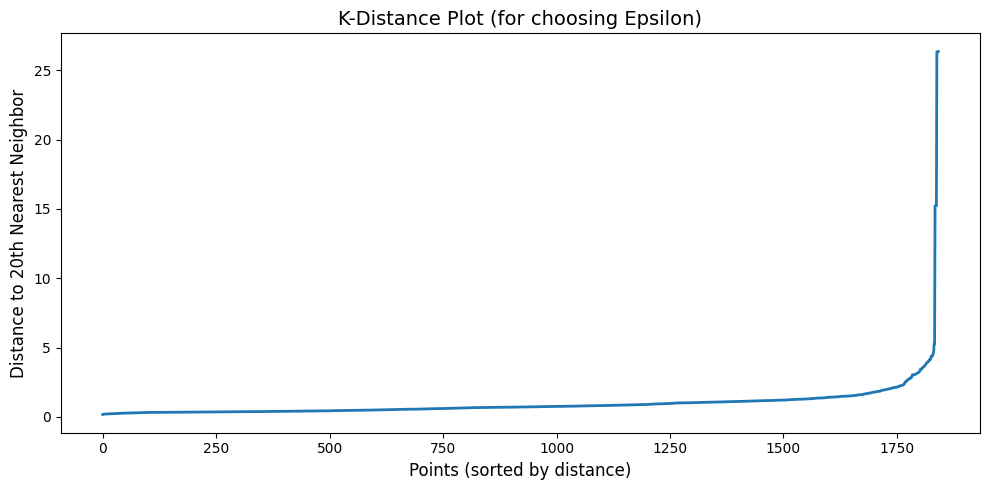

In [56]:
# K-Distance plot helps us choose epsilon
# We use min_samples as the k value (common choice: 2 * n_features) which is the rule of thumb
min_samples = 2 * len(clustering_features)  # 2 * 10 = 20
print(f"min_samples = {min_samples}")

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_scaled)
distances, indices = nn.kneighbors(X_scaled)

# Sort the distance to the k-th nearest neighbor
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, linewidth=2)
plt.xlabel('Points (sorted by distance)', fontsize=12)
plt.ylabel(f'Distance to {min_samples}th Nearest Neighbor', fontsize=12)
plt.title('K-Distance Plot (for choosing Epsilon)', fontsize=14)
plt.tight_layout()
plt.show()

## Interpreting the K-Distance Plot
- Basically looking at the profs notebook getting this plot and choosing a point in the Y-axis up to 4.5 before it shoots up will be the 'correct' point to choose for our epsilon
- This plot helps the analysts (US) choose an optimal point

In [55]:
# Test a range of epsilon values around the elbow you see in the K-Distance plot
eps_values = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]

# this print is just for aesthetics, it makes us columns and makes the table look nice
print(f"{'eps':<8} {'min_samples':<14} {'n_clusters':<12} {'noise_pct':<12} {'silhouette':<12}")
print("=" * 58)

for eps in eps_values:
    # running the DBSCAN algorithm
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)

    # looking through all the points figuring out which are close tgt, groups them and assigns each point a cluster number (if -1, its just noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    # get the percentage of noise each cluster (basically if its assigned -1)
    noise_pct = (labels == -1).sum() / len(labels) * 100

    if n_clusters >= 2:
        # silhouette only works with 2+ clusters, exclude noise points
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask])
        print(f"{eps:<8} {min_samples:<14} {n_clusters:<12} {noise_pct:<12.1f} {sil:<12.3f}")
    else:
        print(f"{eps:<8} {min_samples:<14} {n_clusters:<12} {noise_pct:<12.1f} {'N/A':<12}")

eps      min_samples    n_clusters   noise_pct    silhouette  
1.0      20             11           21.0         0.231       
1.5      20             6            4.6          0.409       
2.0      20             6            3.3          0.405       
2.5      20             6            2.7          0.402       
3.0      20             4            1.6          0.369       
3.5      20             3            0.6          0.393       
4.0      20             2            0.4          0.534       
4.5      20             2            0.4          0.534       


In [68]:
# REPLACE eps with the best value from the table above
BEST_EPS = 1.5  # this number is grabbed from the table above where we get the best silhouette to n_clusters

final_db = DBSCAN(eps=BEST_EPS, min_samples=min_samples)
data_clean['cluster'] = final_db.fit_predict(X_scaled)

n_clusters = len(set(data_clean['cluster'])) - (1 if -1 in data_clean['cluster'] else 0)
noise_count = (data_clean['cluster'] == -1).sum()

print(f"Number of clusters: {n_clusters}")
print(f"Noise points: {noise_count} ({noise_count/len(data_clean)*100:.1f}%)")
print(f"\nCluster sizes:")
print(data_clean['cluster'].value_counts().sort_index())

Number of clusters: 7
Noise points: 85 (4.6%)

Cluster sizes:
cluster
-1      85
 0    1240
 1     146
 2     118
 3     173
 4      59
 5      21
Name: count, dtype: int64


In [69]:
# Exclude noise (-1) for profiling
df_clustered = data_clean[data_clean['cluster'] != -1]

profile = df_clustered.groupby('cluster')[['rent', 'bedrooms', 'square_meters', 'floor',
        'outer', 'elevator', 'penthouse', 'cottage', 'duplex',
        'semidetached']].mean().round(2)
print(profile)

            rent  bedrooms  square_meters  floor  outer  elevator  penthouse  \
cluster                                                                        
0        1607.84      2.26         101.57   3.46    1.0       1.0        0.0   
1         938.39      2.10          66.48   2.13    1.0       0.0        0.0   
2        1989.86      2.07         113.41   5.80    1.0       1.0        1.0   
3        1316.27      1.80          70.21   2.94    0.0       1.0        0.0   
4         813.71      1.53          50.37   1.44    0.0       0.0        0.0   
5        1220.43      1.62          92.29   2.67    1.0       1.0        0.0   

         cottage  duplex  semidetached  
cluster                                 
0            0.0     0.0           0.0  
1            0.0     0.0           0.0  
2            0.0     0.0           0.0  
3            0.0     0.0           0.0  
4            0.0     0.0           0.0  
5            0.0     1.0           0.0  


In [70]:
district_profile = pd.crosstab(df_clustered['cluster'], df_clustered['district'], normalize='index') * 100
district_profile = district_profile.round(1)

for cluster in sorted(df_clustered['cluster'].unique()):
    top_districts = district_profile.loc[cluster].sort_values(ascending=False).head(5)
    print(f"\n--- Cluster {cluster} - Top Districts ---")
    print(top_districts)


--- Cluster 0 - Top Districts ---
district
Salamanca    13.5
Centro       12.6
Chamartín    12.3
Chamberí      8.2
Tetuán        8.1
Name: 0, dtype: float64

--- Cluster 1 - Top Districts ---
district
Centro             17.8
Carabanchel        13.0
Tetuán              9.6
Puente Vallecas     8.9
Chamberí            6.8
Name: 1, dtype: float64

--- Cluster 2 - Top Districts ---
district
Salamanca     26.3
Centro        14.4
Chamberí      11.9
Fuencarral     7.6
Chamartín      6.8
Name: 2, dtype: float64

--- Cluster 3 - Top Districts ---
district
Salamanca    24.3
Chamberí     20.2
Centro       19.1
Retiro       12.1
Chamartín     8.1
Name: 3, dtype: float64

--- Cluster 4 - Top Districts ---
district
Centro        30.5
Chamberí      13.6
Tetuán        11.9
Vicálvaro     10.2
Arganzuela     8.5
Name: 4, dtype: float64

--- Cluster 5 - Top Districts ---
district
Tetuán           28.6
Hortaleza        19.0
Chamartín        14.3
Ciudad Lineal    14.3
Salamanca         9.5
Name: 5, dtype: 

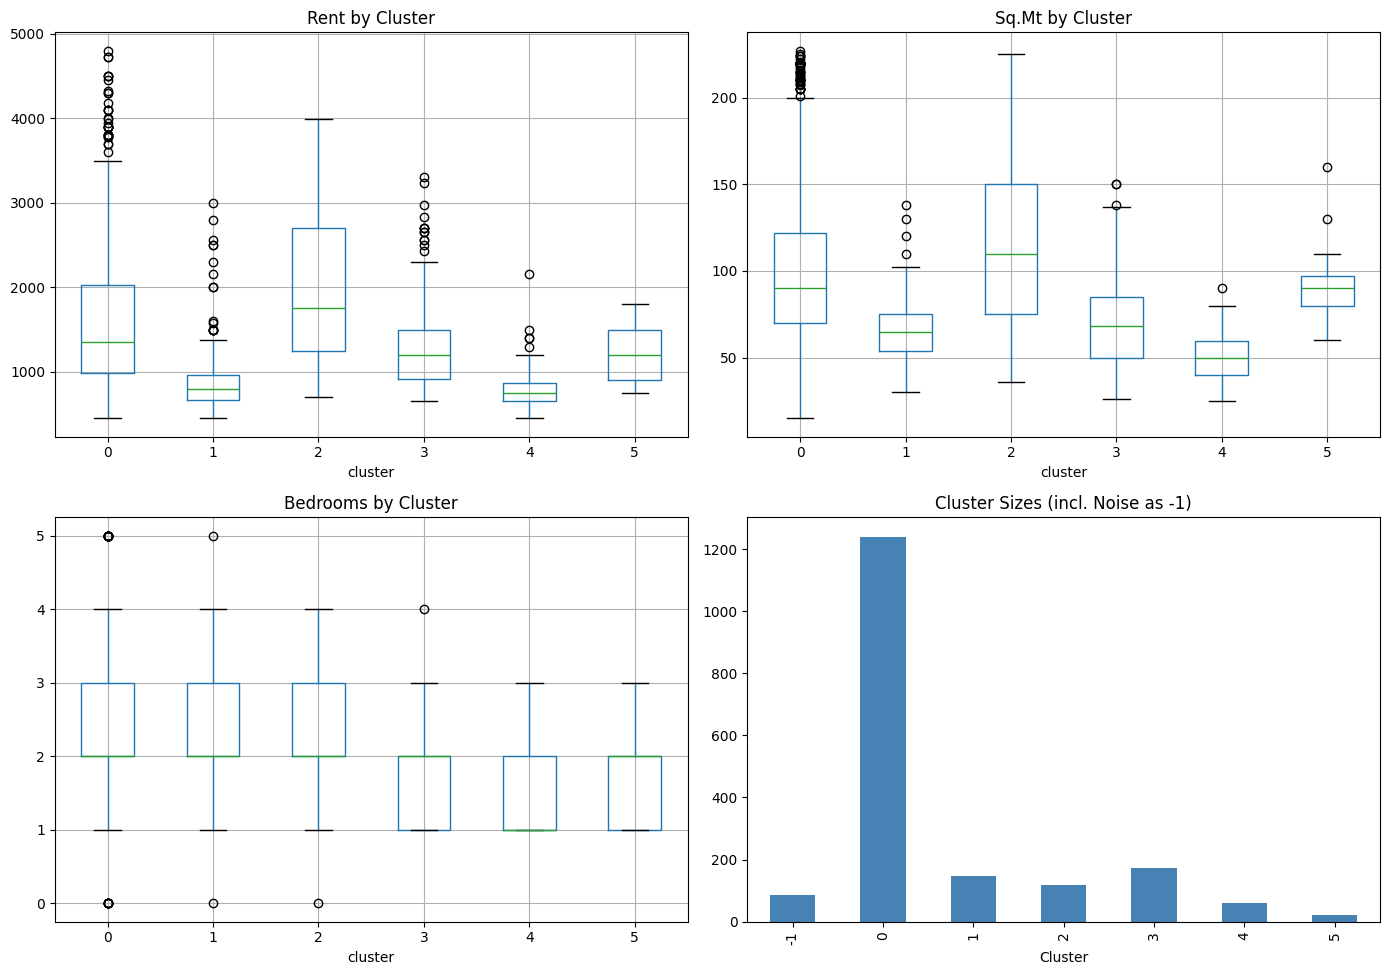

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_clustered.boxplot(column='rent', by='cluster', ax=axes[0,0])
axes[0,0].set_title('Rent by Cluster')

df_clustered.boxplot(column='square_meters', by='cluster', ax=axes[0,1])
axes[0,1].set_title('Sq.Mt by Cluster')

df_clustered.boxplot(column='bedrooms', by='cluster', ax=axes[1,0])
axes[1,0].set_title('Bedrooms by Cluster')

data_clean['cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Cluster Sizes (incl. Noise as -1)')
axes[1,1].set_xlabel('Cluster')

plt.suptitle('')
plt.tight_layout()
plt.show()

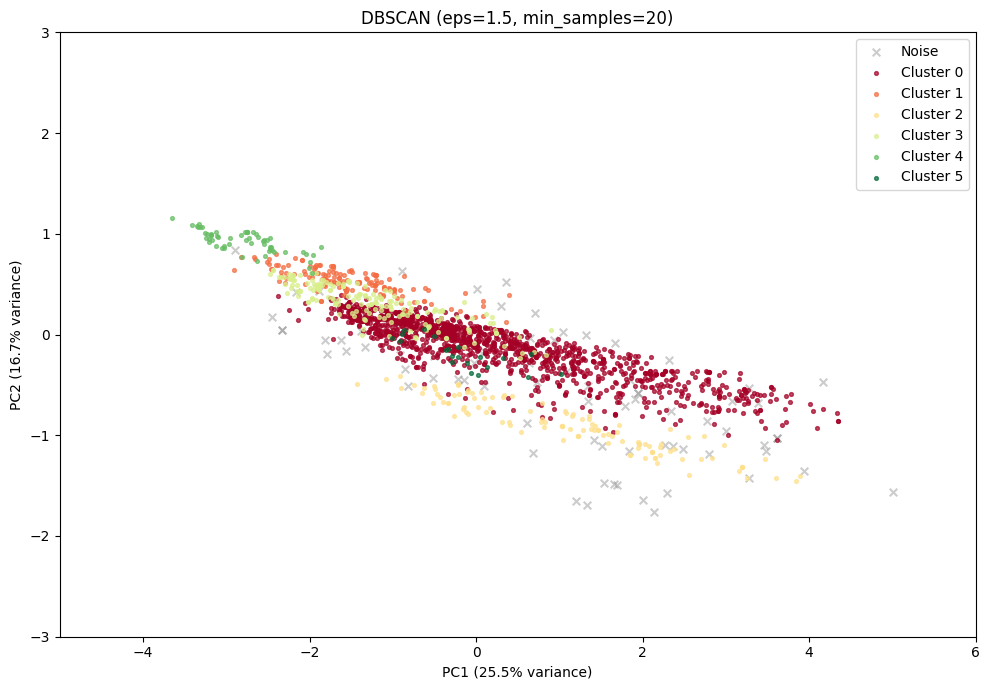

In [67]:
from sklearn.decomposition import PCA
import matplotlib.cm as cm

# PCA used ONLY for 2D visualization — clustering is performed on all original features
pca_viz = PCA(n_components=2)
X_pca = pca_viz.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

# Plot noise points in grey first
noise_mask = data_clean['cluster'] == -1
plt.scatter(
    X_pca[noise_mask, 0], X_pca[noise_mask, 1],
    marker="x", s=30, c='grey', alpha=0.4, label='Noise'
)

# Plot each cluster
n_clusters = len(set(data_clean['cluster'])) - (1 if -1 in data_clean['cluster'].values else 0)
colors = cm.RdYlGn (np.linspace(0, 1, n_clusters))

for cluster_id, color in zip(range(n_clusters), colors):
    mask = data_clean['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        marker=".", s=30, alpha=0.7, c=[color], label=f'Cluster {cluster_id}'
    )

plt.title(f'DBSCAN (eps={BEST_EPS}, min_samples={min_samples})')
plt.xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()
plt.xlim(-5, 6)
plt.ylim(-3, 3)
plt.tight_layout()
plt.show()

### Feature Selection + Scaling (with district)

In [25]:
district_dummies = pd.get_dummies(data_clean['district'], prefix='district', drop_first=False)
district_dummies.columns = district_dummies.columns.str.replace(' ', '_')

clustering_features_wd = numerical_features + binary_features
df_clustering_wd = pd.concat([data_clean[clustering_features_wd], district_dummies], axis=1)

scaler_wd = StandardScaler()
X_scaled_wd = scaler_wd.fit_transform(df_clustering_wd)

print(f"Features: {df_clustering_wd.shape[1]} (10 original + {len(district_dummies.columns)} district dummies)")

Features: 30 (10 original + 20 district dummies)


In [ ]:
# min_samples_wd = 2 * df_clustering_wd.shape[1]
# print(f"min_samples = {min_samples_wd}")

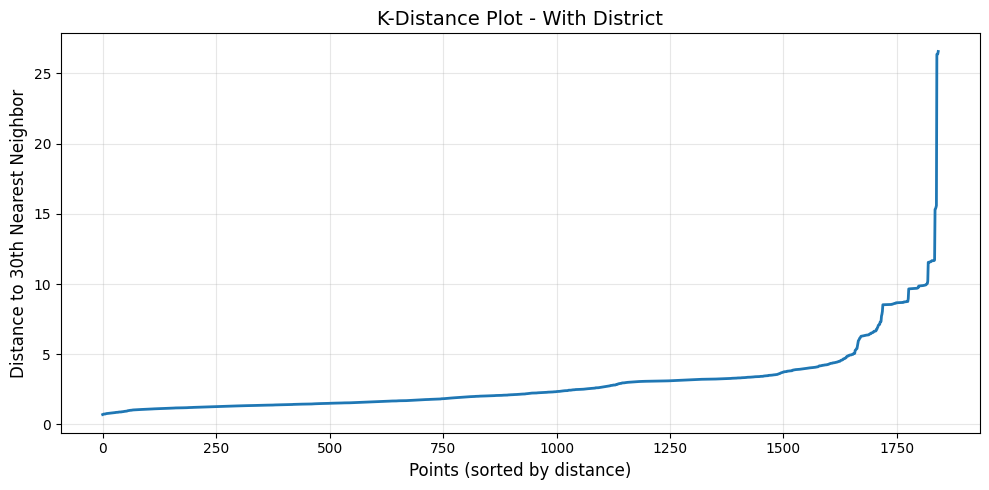

In [42]:
min_samples_wd = 30     # no rule of thumb, will ask the professor see wsg

nn_wd = NearestNeighbors(n_neighbors=min_samples_wd)
nn_wd.fit(X_scaled_wd)
distances_wd, _ = nn_wd.kneighbors(X_scaled_wd)

k_distances_wd = np.sort(distances_wd[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances_wd, linewidth=2)
plt.xlabel('Points (sorted by distance)', fontsize=12)
plt.ylabel(f'Distance to {min_samples_wd}th Nearest Neighbor', fontsize=12)
plt.title('K-Distance Plot - With District', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
eps_values_wd = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]

print(f"{'eps':<8} {'min_samples':<14} {'n_clusters':<12} {'noise_pct':<12} {'silhouette':<12}")
print("=" * 58)

for eps in eps_values_wd:
    db = DBSCAN(eps=eps, min_samples=min_samples_wd)
    labels = db.fit_predict(X_scaled_wd)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100

    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X_scaled_wd[mask], labels[mask])
        print(f"{eps:<8} {min_samples_wd:<14} {n_clusters:<12} {noise_pct:<12.1f} {sil:<12.3f}")
    else:
        print(f"{eps:<8} {min_samples_wd:<14} {n_clusters:<12} {noise_pct:<12.1f} {'N/A':<12}")

eps      min_samples    n_clusters   noise_pct    silhouette  
2.0      30             15           38.9         0.538       
2.5      30             16           33.5         0.518       
3.0      30             14           28.1         0.495       
3.5      30             16           15.1         0.496       
4.0      30             15           10.1         0.472       
4.5      30             12           9.4          0.355       
5.0      30             11           9.2          0.337       
5.5      30             8            9.2          0.281       
6.0      30             7            7.5          0.281       
6.5      30             5            6.7          0.256       
7.0      30             3            6.7          0.265       
7.5      30             2            6.7          0.272       
8.0      30             1            6.7          N/A         
8.5      30             1            6.7          N/A         
9.0      30             1            3.6          N/A  

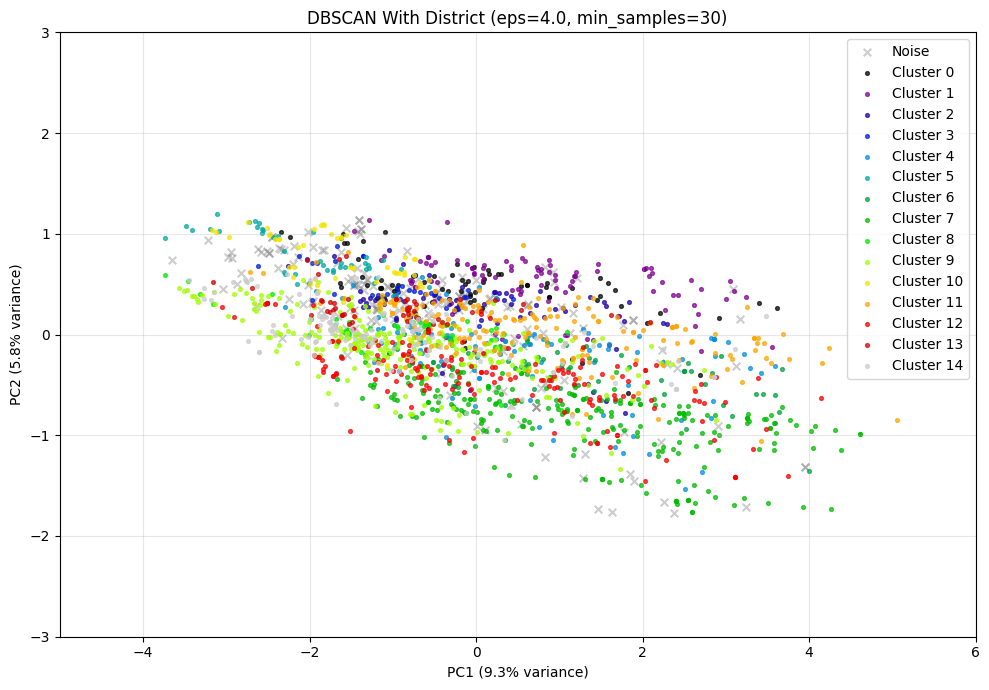


Number of clusters: 15
Noise points: 186

Cluster sizes:
cluster_wd
-1     186
 0      76
 1     100
 2      68
 3      36
 4     102
 5      43
 6      74
 7     250
 8      50
 9     260
 10     52
 11    183
 12    172
 13     56
 14    134
Name: count, dtype: int64


In [47]:
BEST_EPS_WD = 4.0  # we adjust this based on the table above

final_db_wd = DBSCAN(eps=BEST_EPS_WD, min_samples=min_samples_wd)
data_clean['cluster_wd'] = final_db_wd.fit_predict(X_scaled_wd)

# PCA used ONLY for 2D visualization
pca_wd = PCA(n_components=2)
X_pca_wd = pca_wd.fit_transform(X_scaled_wd)

plt.figure(figsize=(10, 7))

noise_mask = data_clean['cluster_wd'] == -1
plt.scatter(
    X_pca_wd[noise_mask, 0], X_pca_wd[noise_mask, 1],
    marker="x", s=30, c='grey', alpha=0.4, label='Noise'
)

n_clusters = len(set(data_clean['cluster_wd'])) - (1 if -1 in data_clean['cluster_wd'].values else 0)
colors = cm.nipy_spectral(np.linspace(0, 1, n_clusters))

for cluster_id, color in zip(range(n_clusters), colors):
    mask = data_clean['cluster_wd'] == cluster_id
    plt.scatter(
        X_pca_wd[mask, 0], X_pca_wd[mask, 1],
        marker=".", s=30, alpha=0.7, c=[color], label=f'Cluster {cluster_id}'
    )

plt.title(f'DBSCAN With District (eps={BEST_EPS_WD}, min_samples={min_samples_wd})')
plt.xlabel(f"PC1 ({pca_wd.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_wd.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.xlim(-5, 6)
plt.ylim(-3, 3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nNumber of clusters: {n_clusters}")
print(f"Noise points: {(data_clean['cluster_wd'] == -1).sum()}")
print(f"\nCluster sizes:")
print(data_clean['cluster_wd'].value_counts().sort_index())

# Exporting the DBSCAN dataset

In [73]:
cluster_0 = df_dbscan[df_dbscan['cluster'] == 0].copy()

print(f"Cluster 0: {len(cluster_0)} properties ({len(cluster_0)/len(df_dbscan)*100:.1f}%)")
print(f"\nRent:     €{cluster_0['rent'].mean():.0f} avg (€{cluster_0['rent'].min()} - eur {cluster_0['rent'].max()})")
print(f"Size:     {cluster_0['square_meters'].mean():.0f} m^2 avg")
print(f"Bedrooms: {cluster_0['bedrooms'].mean():.1f} avg")
print(f"Floor:    {cluster_0['floor'].mean():.1f} avg")
print(f"\nTop 5 Districts:")
print(cluster_0['district'].value_counts().head(5))

Cluster 0: 1248 properties (69.6%)

Rent:     €1614 avg (€450 - eur 4800)
Size:     102 m^2 avg
Bedrooms: 2.3 avg
Floor:    3.5 avg

Top 5 Districts:
district
Salamanca    168
Centro       156
Chamartín    154
Chamberí     102
Tetuán       102
Name: count, dtype: int64


In [74]:
cluster_0.to_excel("cluster_0_phase2_DBSCAN.xlsx", index=False)
print(f"Exported {len(cluster_0)} rows to cluster_0_phase2_DBSCAN.xlsx")

Exported 1248 rows to cluster_5_phase2.xlsx
